<a href="https://colab.research.google.com/github/phantrang184/Data-analysis-in-business-lecture-assignment/blob/main/Fators%20affect%20Clothing%20stores%20profi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PTDL/Clothing.csv')
df.head()

,tsales,sales,margin,nown,nfull,npart,naux,hoursw,hourspw,inv1,inv2,ssize,start
0,750000,4411.765,41.0,1.0,1.0000,1.0000,1.5357,76,16.75596,17166.67,27177.04,170,41.0
1,1926395,4280.878,39.0,2.0,2.0000,3.0000,1.5357,192,22.49376,17166.67,27177.04,450,39.0
2,1250000,4166.667,40.0,1.0,2.0000,2.2222,1.4091,114,17.19120,292857.20,71570.55,300,40.0
3,694227,2670.104,40.0,1.0,1.0000,1.2833,1.3673,100,21.50260,22207.04,15000.00,260,40.0
4,750000,15000.000,44.0,2.0,1.9556,1.2833,1.3673,104,15.74279,22207.04,10000.00,50,44.0


# 1. Làm sạch dữ liệu

In [ ]:
# Chuẩn hóa
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [ ]:
X = df.drop(columns=['tsales'])  # biến độc lập
y = df['tsales']                 # biến phụ thuộc

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
# Bỏ biến phụ thuộc
vif_df = df.drop(columns=['tsales'])
vif_df = add_constant(vif_df)
# Tính VIF
vif_data = pd.DataFrame()
vif_data["Features"] = vif_df.columns
vif_data["VIF"] = [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]

# Sắp xếp theo VIF giảm dần để dễ loại bỏ
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# Hiển thị kết quả VIF
print(vif_data)

   Features         VIF
0     const  193.691894
7    hoursw   23.186053
8   hourspw   13.362686
4     nfull    4.543530
3      nown    2.766915
11    ssize    2.677055
5     npart    1.809831
1     sales    1.746494
6      naux    1.545494
2    margin    1.450129
12    start    1.390845
9      inv1    1.356078
10     inv2    1.322350


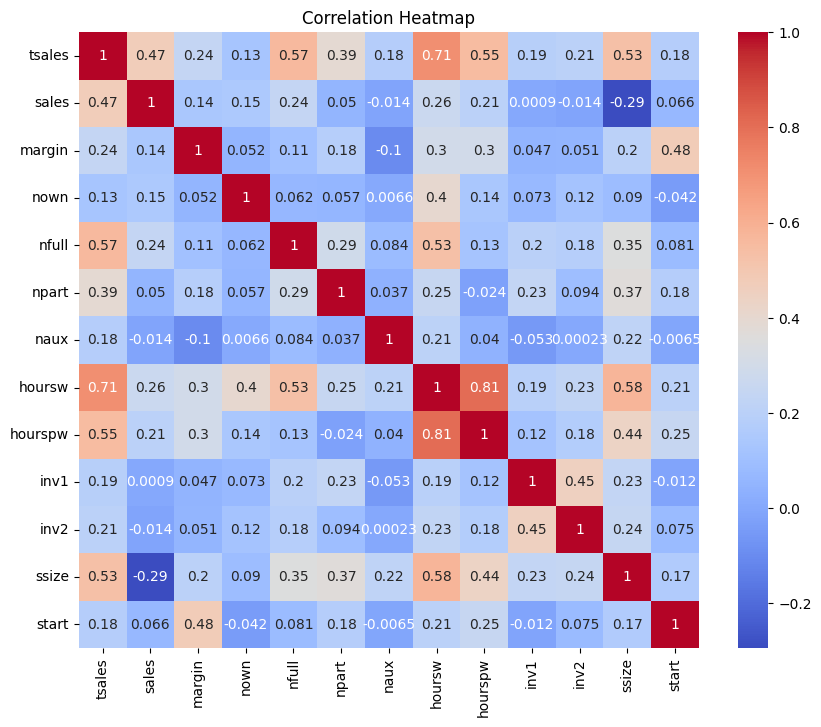

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Nhận xét chung về Heatmap:
1. Mối quan hệ giữa doanh thu (tsales) và các yếu tố khác:
hoursw (Tổng giờ làm việc) có tương quan 0.71, cho thấy tổng thời gian làm việc có ảnh hưởng lớn đến doanh thu.
nfull (Số nhân viên toàn thời gian) có tương quan 0.57, chứng tỏ nhân viên toàn thời gian đóng vai trò quan trọng trong việc tăng doanh thu.
ssize (Diện tích cửa hàng) có tương quan 0.53, cho thấy cửa hàng lớn thường có doanh thu cao hơn.
hourspw (Giờ làm của nhân viên bán thời gian) có tương quan 0.55, thể hiện tác động đến doanh thu nhưng yếu hơn so với nhân viên toàn thời gian.
2. Mối quan hệ giữa doanh số bán hàng (sales) và các yếu tố khác:
tsales (Tổng doanh thu) có tương quan 0.47, cho thấy doanh số có ảnh hưởng đến doanh thu nhưng không phải yếu tố quyết định.
ssize (Diện tích cửa hàng) có tương quan -0.29, chứng tỏ cửa hàng lớn không nhất thiết có doanh số cao hơn, có thể do yếu tố chiến lược kinh doanh.
3. Mối quan hệ giữa các yếu tố nhân sự:
hoursw (Tổng giờ làm việc toàn thời gian) và hourspw (Giờ làm bán thời gian) có tương quan 0.81, cho thấy mối quan hệ rất chặt chẽ, có thể gây đa cộng tuyến.
nfull (Nhân viên toàn thời gian) và naux (Nhân viên phụ trợ) có tương quan 0.08, tức là gần như không liên quan.
4. Mối quan hệ giữa đầu tư và diện tích cửa hàng:
inv1 (Hàng tồn kho loại 1) và inv2 (Hàng tồn kho loại 2) có tương quan 0.45, thể hiện sự liên quan giữa hai loại hàng tồn kho.
inv2 và ssize (Diện tích cửa hàng) có tương quan 0.23, cho thấy cửa hàng lớn có xu hướng tồn kho nhiều hơn.
5. Mối quan hệ giữa thời gian hoạt động (start) và các biến khác:
Tương quan thấp với tất cả các biến, cao nhất là 0.17 với ssize, cho thấy thời gian hoạt động không ảnh hưởng đáng kể đến doanh thu hay nhân sự.
Kết luận hoursw và hourspw có tương quan quá cao (0.81) → cần loại bỏ một biến để tránh đa cộng tuyến.
Quyết định loại bỏ hourspw (Giờ làm nhân viên bán thời gian) vì hoursw đã phản ánh tổng số giờ làm việc.
Diện tích cửa hàng (ssize) ảnh hưởng đến doanh thu nhưng không quyết định hoàn toàn, cần xem xét thêm các yếu tố khác như chiến lược kinh doanh.
Kết luận:
hoursw và hourspw có tương quan quá cao (0.81) → cần loại bỏ một biến để tránh đa cộng tuyến.
Quyết định loại bỏ hourspw (Giờ làm nhân viên bán thời gian) vì hoursw đã phản ánh tổng số giờ làm việc.
Diện tích cửa hàng (ssize) ảnh hưởng đến doanh thu nhưng không quyết định hoàn toàn, cần xem xét thêm các yếu tố khác như chiến lược kinh doanh.


**Kết luận sau khi kiểm tra đa cộng tuyến:**

Vì các chỉ số 'hourspw', 'hoursw' có chỉ số VIF >10 và nfull có VIF >3 nên chúng ta sẽ xem xét xử lý các biến này để tránh đa cộng tuyến.
- Hoursw và hourspw tỷ lệ thuận với nhau qua hourspw = hoursw/weeks. Tuy nhiên, giờ làm việc tỷ lệ thuận với số lượng nhân viên, đặc biệt là nhân viên fulltime
- hoursw và nfull có mối tương tác trên heatmap, vì thời gian làm việc tỷ lệ thuận với số lượng nhân viên (trong đó nhân viên fulltime ảnh hưởng nhiều hơn do làm nhiều giờ hơn so với các nhóm khác)
- nfull, npart, naux: Đều đại diện cho các loại nhân viên, dễ xảy ra mối quan hệ cộng gộp. Nhưng naux tác động tới biến phụ thuộc tsales không quá nhiều 0.18 (vì Số nhân viên phụ trợ không quá nhiều và không ảnh hưởng lớn hiệu suất làm việc của cửa hàng)

=>> Nhóm loại biến hoursw

In [ ]:
df_reduced = df.drop(columns=['hoursw'])

# 2. Làm sạch và Thống kê mô tả

In [ ]:
#Xử lí dữ liệu thiếu
df.isnull().sum()

In [ ]:
#Xử lí dữ liệu trùng lặp
df.duplicated().sum()

In [ ]:
df.info()
df.describe()

**TÍNH TRUNG BÌNH TỪNG BIẾN TRONG CỘT**

In [ ]:
numeric_means = df.select_dtypes(include=np.number).mean()
numeric_means

1. Hiệu suất kinh doanh:
Doanh thu trung bình ~833,584 guilders/năm, hiệu quả sử dụng diện tích cao (6,335 guilders/m²), biên lợi nhuận ~39% là rất tốt. → Các cửa hàng vận hành hiệu quả, nhưng cần duy trì lợi nhuận gộp >35% và theo dõi doanh thu/m² để phát hiện cửa hàng yếu.

2. Nhân sự & giờ làm:
Trung bình mỗi cửa hàng có ~5 nhân viên, nhưng mỗi người chỉ làm ~19 giờ/tuần → cho thấy phần lớn là bán thời gian. Hiệu suất lao động còn thấp. → Nên đào tạo nâng năng suất, ưu tiên tuyển dụng full-time để ổn định vận hành, giảm phụ thuộc part-time.

3. Đầu tư:
Đầu tư mặt bằng cao gấp đôi công nghệ (58k vs 28k guilders). → Chưa tối ưu hoá công nghệ. Cần tăng đầu tư vào tự động hóa (POS, quản lý hàng tồn...) để nâng hiệu quả vận hành, đặc biệt nếu muốn mở rộng hoặc giảm nhân sự.

4. Đặc điểm hoạt động:
Các cửa hàng có tuổi đời trung bình ~43 năm. → Lợi thế kinh nghiệm, khách quen, nhưng dễ bảo thủ, thiếu đổi mới. Cần đánh giá hiệu quả giữa cửa hàng mới và lâu năm để ra quyết định cải tổ, đổi mới phù hợp.

=> Doanh thu tốt, vận hành ổn, nhưng còn dư địa nâng hiệu suất lao động và áp dụng công nghệ. Nên tái phân bổ đầu tư, tinh gọn nhân sự, tăng tự động hóa và đo lường hiệu quả để phát triển bền vững hơn.


**TÍNH TRUNG VỊ**

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
medians = df[numeric_cols].median()
medians

1. Doanh thu (tsales)
Mean: 833,584

Median: 694,227
→ Trung bình > trung vị → Có một số cửa hàng doanh thu rất cao kéo trung bình lên → dữ liệu lệch phải, tồn tại outliers.

2. Sales trên m² (sales)
Mean: 6,335

Median: 5,279
→ Tình trạng tương tự: một số cửa hàng có hiệu suất rất cao → nên kiểm tra top 10 cửa hàng vượt trội để rút kinh nghiệm hoặc phân tích riêng.

3. Margin
Mean ~38.77%, Median = 39%
→ Phân phối khá cân đối, không bị lệch → dữ liệu ổn định, đáng tin.

4. Nhân sự (nfull, npart, naux)
Mean và median gần nhau → Không có sự khác biệt lớn, cơ cấu nhân sự ổn định.

5. Giờ làm (hoursw, hourspw)
Mean > median → Một số cửa hàng có số giờ làm rất cao → kiểm tra xem hiệu quả có tương xứng.

6. Đầu tư
inv1: Mean = 58k, Median = 22k

inv2: Mean = 27k, Median = 22k
→ Đầu tư vào mặt bằng bị lệch mạnh, nhiều cửa hàng đầu tư rất cao → kiểm tra lại ROI (lợi nhuận/đầu tư).

7. Diện tích (ssize)
Mean = 151m², Median = 120m²
→ Một số cửa hàng diện tích rất lớn → ảnh hưởng đến phân tích hiệu quả theo diện tích → nên chia nhóm theo quy mô để đánh giá chính xác hơn.



**TÌM MODE CHO CÁC BIẾN TRONG CỘT**

In [ ]:
modes = {}
for col in df.columns:
    # Determine the data type of the column
    if pd.api.types.is_numeric_dtype(df[col]):
        # For numeric columns, calculate the mode
        modes[col] = df[col].mode().iloc[0] if not df[col].mode().empty else "No mode found"  # Handle cases with no mode
    elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
        # For categorical or object columns (likely strings), calculate the mode
        modes[col] = df[col].mode().iloc[0] if not df[col].mode().empty else "No mode found"  # Handle cases with no mode
    else:
        modes[col] = "Unsupported data type"


for col, mode in modes.items():
    print(f"Mode of column '{col}': {mode}")

Doanh thu phổ biến là ~977,000, cao hơn cả trung bình và trung vị → một nhóm cửa hàng hoạt động rất tốt.

Hiệu suất phổ biến là 5,000/m², thấp hơn trung bình → chứng tỏ có nhiều cửa hàng nhỏ, hiệu suất tầm trung, trong khi một vài cửa hàng có hiệu suất cực cao kéo mean lên.

Biên lợi nhuận phổ biến là 41%, cho thấy phần lớn cửa hàng đặt mục tiêu khá cao về lãi gộp – một dấu hiệu tích cực.

Nhân sự khá đồng đều, hầu hết có 1 chủ, ~2 full-time, ~1-1.3 part-time → setup nhân sự cơ bản, không quá cồng kềnh.

Giờ làm việc phổ biến lại khá thấp (80h/tổng, ~7.7h/người) → có thể là những cửa hàng nhỏ, hoạt động không liên tục, hoặc bán part-time, bán thêm.

Đầu tư phổ biến ~22,000 cho cả mặt bằng và công nghệ → vừa phải, hợp với quy mô nhỏ và vừa.

Diện tích phổ biến là 100m² → khá nhỏ, xác nhận phần lớn cửa hàng là mô hình mini hoặc boutique.



**PHÉP ĐO ĐỘ PHÂN TÁN**

**TÍNH KHOẢNG BIẾN THIÊN**

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)
max_values = numeric_cols.max()
min_values = numeric_cols.min()
ranges = max_values - min_values
print("\nRanges:\n", ranges)

1. Doanh thu & hiệu suất
tsales: chênh lệch tới 4.95 triệu guilders
→ Có cửa hàng doanh thu rất thấp, có cửa hàng doanh thu siêu cao → chênh lệch rất lớn, dễ làm sai lệch kết quả nếu không tách nhóm.

sales: chênh 26,700 guilders/m²
→ Có cửa hàng bán được rất nhiều trên mỗi m², nhưng cũng có nơi bán rất ít → hiệu suất sử dụng mặt bằng không đồng đều.

2. Biên lợi nhuận
margin: chênh lệch tới 50%
→ Có nơi lời rất nhiều, có nơi lời rất ít → thể hiện chiến lược giá và chi phí vận hành rất khác nhau.

3. Nhân sự
nown (số chủ/quản lý): chênh 9 người

nfull, npart, naux: chênh từ 3–8 người
→ Có cửa hàng chỉ 1 người làm tất cả, có nơi có cả team đông đảo → quy mô tổ chức rất khác biệt.

4. Giờ làm việc
hoursw: chênh lệch tới 550 giờ/tuần
→ Có nơi gần như không hoạt động, có nơi mở cửa cả tuần, làm việc liên tục → cần kiểm tra kỹ để tránh đánh giá sai hiệu suất.

hourspw: dao động tới 37.6 giờ/người
→ Có nhân viên làm chỉ vài giờ/tuần, có người làm full-time → sự phân hóa cao trong mô hình hoạt động.

5. Đầu tư & diện tích
inv1: chênh tới 1.49 triệu guilders

inv2: gần 400,000 guilders
→ Có cửa hàng đầu tư cực lớn vào mặt bằng và công nghệ → khả năng là chuỗi lớn hoặc flagship store.

ssize: diện tích chênh lệch gần 1,200m²
→ Có cửa hàng rất nhỏ, có nơi rộng như trung tâm thương mại → nếu không chia nhóm thì sẽ rất dễ so sánh sai.

6. Năm hoạt động (start)
Chênh lệch tới 74 năm
→ Có cửa hàng mở từ rất lâu, có nơi mới mở gần đây → ảnh hưởng tới kinh nghiệm, tệp khách hàng, mô hình vận hành.

**Tính phương sai**

In [ ]:
variances = df[numeric_cols.columns].var()
print("\nVariances:\n", variances)

 1. Phân tán rất lớn
tsales = 3.4 × 10¹¹, sales = 1.4 × 10⁷
→ Doanh thu và hiệu suất bán hàng phân tán cực kỳ mạnh. Có cửa hàng rất cao, có nơi rất thấp → ảnh hưởng lớn đến phân tích trung bình → nên dùng trung vị (median) thay vì mean.

inv1 = 1.16 × 10¹⁰, inv2 = 1.72 × 10⁹, ssize = 1.26 × 10⁴
→ Đầu tư và diện tích cũng cực kỳ không đồng đều → có vài cửa hàng đầu tư khủng hoặc quy mô lớn vượt trội.

Những biến này nên kiểm tra outlier hoặc chia nhóm trước khi phân tích sâu.

2. Phân tán trung bình
margin = ~27.2
→ Biên lợi nhuận dao động vừa phải → mỗi cửa hàng có một chiến lược giá khác nhau, nhưng nhìn chung không bị lệch quá mức.

hourspw = ~53.9
→ Giờ làm việc theo người cũng dao động nhiều → người thì chỉ làm 5–10h/tuần, có người làm tới 40h → cần kiểm tra thêm xem ai hiệu quả.

3. Phân tán thấp
nown, nfull, npart, naux đều < 1.0
→ Cơ cấu nhân sự nhìn chung khá đồng đều giữa các cửa hàng. Không có cửa hàng nào quá đông nhân sự hoặc quá thiếu hụt.

hoursw (tổng giờ làm) = 4,151
→ Cũng khá đồng đều nếu so với các biến đầu tư hay doanh thu, mặc dù vẫn có một số khác biệt rõ.

**Tìm tứ phân vị**

In [ ]:
# Danh sách biến định lượng
numerical_cols = [ 'tsales', 'sales', 'margin', 'nown', 'nfull', 'npart', 'naux',
    'hoursw', 'hourspw', 'inv1', 'inv2', 'ssize', 'start']


# Tính Q1, Q2, Q3
Q1 = df[numerical_cols].quantile(0.25)
Q2 = df[numerical_cols].quantile(0.50)
Q3 = df[numerical_cols].quantile(0.75)


# In ra kết quả
print("Tứ phân vị (Q1, Q2, Q3):")
print("Q1 - Phân vị thứ 1 (25%):")
print(Q1)
print("\nQ2 - Trung vị (50%):")
print(Q2)
print("\nQ3 - Phân vị thứ 3 (75%):")
print(Q3)


1. Doanh thu (tsales)
Q1 = 495,340 → 25% cửa hàng có doanh thu thấp hơn mức này.

Q2 = 694,227 → Mức doanh thu trung bình của toàn bộ hệ thống.

Q3 = 976,817 → 25% cửa hàng có doanh thu vượt ngưỡng này.

Ý nghĩa:
Doanh thu giữa các cửa hàng chênh lệch khá lớn. Một số cửa hàng có doanh thu rất cao, tạo khoảng cách rõ rệt với phần còn lại.
→ Cần tách nhóm top 25% để phân tích bí quyết vận hành (vị trí, sản phẩm, nhân sự...).

2. Hiệu suất bán hàng (sales)
Q1 = 3,904 | Q2 = 5,279 | Q3 = 7,739
Ý nghĩa:
Hiệu quả sử dụng mặt bằng giữa các cửa hàng khác biệt rõ. Nhóm top (> Q3) đang tận dụng mặt bằng cực tốt.
→ Có thể có layout tối ưu, vị trí tốt hoặc nhân viên bán hàng giỏi.

3. Biên lợi nhuận (margin)
Q1 = 37% | Q2 = 39% | Q3 = 41%

Ý nghĩa:
Chênh lệch không lớn → Hầu hết cửa hàng đều có biên lợi nhuận tương đối tốt và ổn định.
→ Đây là yếu tố đáng giữ vững, thể hiện khả năng kiểm soát chi phí và định giá hợp lý.

4. Nhân sự (nown, nfull, npart, naux)
Các tứ phân vị đều sát nhau → phân bố đều, không có sự khác biệt quá lớn.

Ý nghĩa:
Cửa hàng vận hành theo mô hình khá giống nhau về số lượng người: 1 chủ, ~2 full-time, ~1-1.3 part-time.
→ Mô hình này có vẻ là công thức "chuẩn" cho các cửa hàng thời trang nam thời điểm đó.

5. Giờ làm việc
hoursw: Q1 = 80h, Q3 = 145h

hourspw: Q1 = 13.5h, Q3 = 24.2h

Ý nghĩa:
Một số cửa hàng hoạt động bán thời gian (rất ít giờ), số khác mở liên tục → ảnh hưởng đến doanh thu và hiệu suất.
→ Cần kiểm tra xem giờ làm có tương xứng với doanh thu không → nếu không, có thể đang vận hành kém hiệu quả.

6. Đầu tư (inv1, inv2)
Mặt bằng: từ 20,000 đến 62,269

Công nghệ: từ 1,000 đến 22,859

Ý nghĩa:
Chênh lệch đầu tư khá lớn giữa các nhóm cửa hàng. Một số đầu tư rất mạnh, một số rất tiết kiệm.
→ Không phải cứ đầu tư nhiều là tốt, cần so sánh với doanh thu để tính ROI (tỷ suất sinh lời).

7. Diện tích (ssize)
Q1 = 100m² | Q3 = 190m²

Ý nghĩa:
Cửa hàng chủ yếu thuộc quy mô nhỏ và vừa. Nhóm lớn hơn (top 25%) nên được phân tích thêm để xem quy mô có giúp tăng hiệu quả không.

8. Năm hoạt động (start)
Q1 = 37 (~1953)

Q3 = 42 (~1948)

Ý nghĩa:
Phần lớn cửa hàng đã hoạt động trên 40 năm → dày dạn kinh nghiệm. Tuy nhiên, cũng cần xem xét xem cửa hàng mới (< Q1) có đang hoạt động hiệu quả hơn không nhờ công nghệ, đổi mới, cách quản lý hiện đại.



**ĐỘ PHÂN PHỐI**

**Tính độ lệch (SKEWNESS)**

In [ ]:
# TÍNH ĐỘ LỆCH (SKEWNESS)
skewness = df[numeric_cols.columns].skew()
print("\nSkewness:\n", skewness)

NameError: name 'df' is not defined

 1. tsales = 2.38
→ Lệch phải mạnh → có một nhóm nhỏ cửa hàng doanh thu rất cao, phần lớn doanh thu tập trung ở nhóm thấp–trung bình.
→ Không dùng mean để phân tích, nên dùng median hoặc chia nhóm.

🧾 2. sales = 1.76
→ Cũng lệch phải → hiệu suất theo m² cao ở một nhóm nhỏ.
→ Một vài cửa hàng sử dụng mặt bằng cực kỳ hiệu quả, nhưng đa số thì không.

3. margin = -0.34
→ Lệch trái nhẹ → một số cửa hàng có biên lợi nhuận thấp bất thường (có thể lỗ hoặc cắt giá sâu).
→ Nhìn chung, biên lợi nhuận ổn định, không bị ảnh hưởng quá lớn.

4. nown = 7.01, nfull = 1.91, npart = 4.12, naux = 3.41
→ Tất cả lệch phải mạnh → phần lớn cửa hàng có ít nhân sự, một vài có rất nhiều người → tạo sự chênh lệch lớn.
→ Cần xem xét lại hiệu quả vận hành khi nhân sự quá đông.

5. hoursw = 2.02, hourspw = 0.59
→ Lệch phải → có cửa hàng làm việc rất nhiều, phần lớn thì hoạt động trung bình hoặc thấp.
→ Có thể do mô hình hoạt động full-time vs bán thời gian.

6. inv1 = 7.04, inv2 = 5.54**
→ Lệch phải cực mạnh → đa số cửa hàng đầu tư vừa phải, một nhóm đầu tư rất cao kéo dữ liệu lệch.
→ Phải kiểm tra hiệu quả đầu tư (doanh thu/chi phí) để biết có đáng không.

7. ssize = 3.26
→ Lệch phải → phần lớn cửa hàng nhỏ, chỉ một vài có diện tích rất lớn.
→ Nên tách nhóm nhỏ – vừa – lớn để so sánh hiệu suất.

8. start = 2.04
→ Lệch phải nhẹ → phần lớn mở từ rất lâu, nhưng vẫn có một số mới hơn.
→ Có thể nghiên cứu hiệu suất giữa nhóm “lâu đời” và nhóm “mới mở”.

**Tính độ nhọn (KURTOSIS)**

In [ ]:
# TÍNH ĐỘ NHỌN (KURTOSIS)
kurtosis = df[numeric_cols.columns].kurt()
print("\nKurtosis:\n", kurtosis)

tsales = 10.30
→ Phân phối rất nhọn → có nhiều cửa hàng có doanh thu bất thường (rất cao) → cần chú ý loại bỏ hoặc phân tích riêng.

sales = 4.77, margin = 3.78
→ Cũng nhọn hơn chuẩn → tồn tại một số cửa hàng có hiệu suất và biên lợi nhuận cao vượt trội → không thể đại diện cho toàn bộ hệ thống.

nown = 86.36 (!), npart = 33.07, naux = 17.12
→ Rất nhọn, tức là đa số cửa hàng có rất ít người, nhưng lại có vài trường hợp cực kỳ đông nhân sự (có thể là chuỗi lớn, hoặc dữ liệu sai).
→ Nên kiểm tra lại các giá trị cao bất thường.

nfull = 5.46
→ Nhọn nhưng không cực đoan → vẫn trong tầm có thể phân tích được.

hoursw = 7.53, hourspw = -0.18
→ Tổng giờ làm có nhiều outliers → có nơi làm cực kỳ nhiều.
→ Nhưng trung bình giờ/người (hourspw) gần như không bị ảnh hưởng → ổn định.

inv1 = 81.45, inv2 = 39.94
→ Cực kỳ nhọn → một số cửa hàng đầu tư cực lớn, số còn lại rất thấp.
→ Nếu không xử lý outlier, sẽ gây sai lệch khi tính trung bình.

ssize = 21.40
→ Phân phối diện tích rất không đều, có một số cửa hàng cực kỳ lớn.

start = 4.05
→ Lệch nhẹ → có thể có một vài cửa hàng mới mở, còn lại mở từ lâu.



**Tính hệ số tương quan (CORRELATION)**


In [ ]:
# Tạo bản sao của DataFrame gốc để tránh làm thay đổi dữ liệu ban đầu
df_encoded = df.copy()
# Chuyển đổi các cột dạng chuỗi (object) thành số bằng Label Encoding
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes
# Lọc ra các cột dạng số sau khi mã hóa
numeric_data = df_encoded.select_dtypes(include=['number'])
# Tính ma trận hệ số tương quan
correlations = numeric_data.corr()
# In kết quả ra
print("Ma trận hệ số tương quan toàn bộ biến (đã mã hóa):")
print(correlations)

1.Biến tsales (tổng doanh thu)
Tương quan mạnh nhất với:

hoursw (0.71): Tổng giờ làm càng cao → doanh thu càng lớn.

hourspw (0.55): Năng suất cá nhân cao → doanh thu cao.

ssize (0.53): Diện tích cửa hàng lớn → doanh thu cao.

sales (0.47): Hiệu suất theo m² ảnh hưởng tốt đến doanh thu.

inv1 (0.20), inv2 (0.21): Đầu tư có tương quan nhẹ với doanh thu.
Gợi ý: Các yếu tố lao động và diện tích có vai trò rất lớn trong tăng doanh thu.

2.Biến nfull (nhân viên toàn thời gian)
Tương quan khá với tsales (0.56), hoursw (0.81), inv1 (0.34)
→ Cửa hàng có nhiều nhân sự chính thức thì tổng giờ làm cao và thường đầu tư nhiều → hiệu quả kinh doanh có thể cao hơn.

3.Biến ssize (diện tích)
Tương quan với:

tsales (0.53), inv1 (0.37), inv2 (0.22): Cửa hàng lớn thường đầu tư nhiều và doanh thu cao.

4.Biến inv1, inv2 (đầu tư)
Tương quan với nhau (0.23), và với tsales, nfull, ssize.
→ Đầu tư vào hạ tầng đi kèm với mở rộng quy mô và doanh thu.

5.Biến không có tương quan rõ ràng
naux, npart: Tương quan rất yếu với doanh thu và các biến chính.
→ Có thể là biến không ảnh hưởng nhiều đến hiệu quả hoạt động.



**PHÉP ĐO LƯỜNG CHỈ SỐ RÀNG BUỘC**

**Tính hiệp phương sai**

In [ ]:
covariances = df[numeric_cols.columns].cov()
print("\nCovariances:\n", covariances)

**Xác định các điểm cá biệt**

In [ ]:
# Danh sách biến định lượng
numerical_cols = [ 'tsales', 'sales', 'margin', 'nown', 'nfull', 'npart', 'naux',
    'hoursw', 'hourspw', 'inv1', 'inv2', 'ssize', 'start']

Q1 = df[numeric_cols.columns].quantile(0.25)
Q3 = df[numeric_cols.columns].quantile(0.75)
IQRs = Q3 - Q1
print("\nInterquartile Ranges (IQRs):\n", IQRs)
for col in numerical_cols:
    lower = Q1[col] - 1.5 * IQRs[col]
    upper = Q3[col] + 1.5 * IQRs[col]
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} điểm cá biệt")

tsales: Chênh lệch doanh thu cho thấy hệ thống có cả cửa hàng lớn vượt trội lẫn cửa hàng hoạt động yếu. Đây là biến nhạy với nhiều yếu tố: vị trí, diện tích, nhân sự, đầu tư.

sales: Phản ánh hiệu suất không gian. Các điểm ngoại lệ cho thấy có nơi tận dụng cực tốt mặt bằng (bán nhiều dù diện tích nhỏ) và ngược lại.

margin: Độ biến động cao. Một số cửa hàng có thể đang định giá cao hơn mức trung bình, hoặc tiết giảm chi phí tốt hơn các cửa hàng còn lại.

nown: Một số cửa hàng do nhiều người cùng sở hữu, gây ra biến động. Có thể liên quan đến phong cách quản trị khác nhau.

nfull & naux: Biến động lớn. Một số nơi dùng nhiều nhân viên cố định hoặc tạm thời, số khác gần như không có. Thể hiện sự đa dạng mô hình vận hành.

npart: Ổn định hơn, cho thấy hầu hết cửa hàng đều dùng part-time với mức tương đương.

hoursw: Tổng giờ làm có chênh lệch. Có thể do khác biệt về số nhân viên hoặc thời gian hoạt động.

hourspw: Ít khác biệt → nhân viên các nơi làm việc với cường độ khá giống nhau.

inv1 & inv2: Một số cửa hàng đầu tư rất nhiều vào cơ sở vật chất và công nghệ, trong khi số khác gần như không đầu tư. Thể hiện mức độ hiện đại hóa không đồng đều.

ssize: Diện tích phản ánh rõ quy mô. Một số cửa hàng có thể là showroom, số khác là kios nhỏ.

start: Có cả cửa hàng rất mới và rất lâu đời → thể hiện lịch sử và kinh nghiệm không đồng đều trong hệ thống.



# 3. Trực quan hóa dữ liệu

## Đơn biến

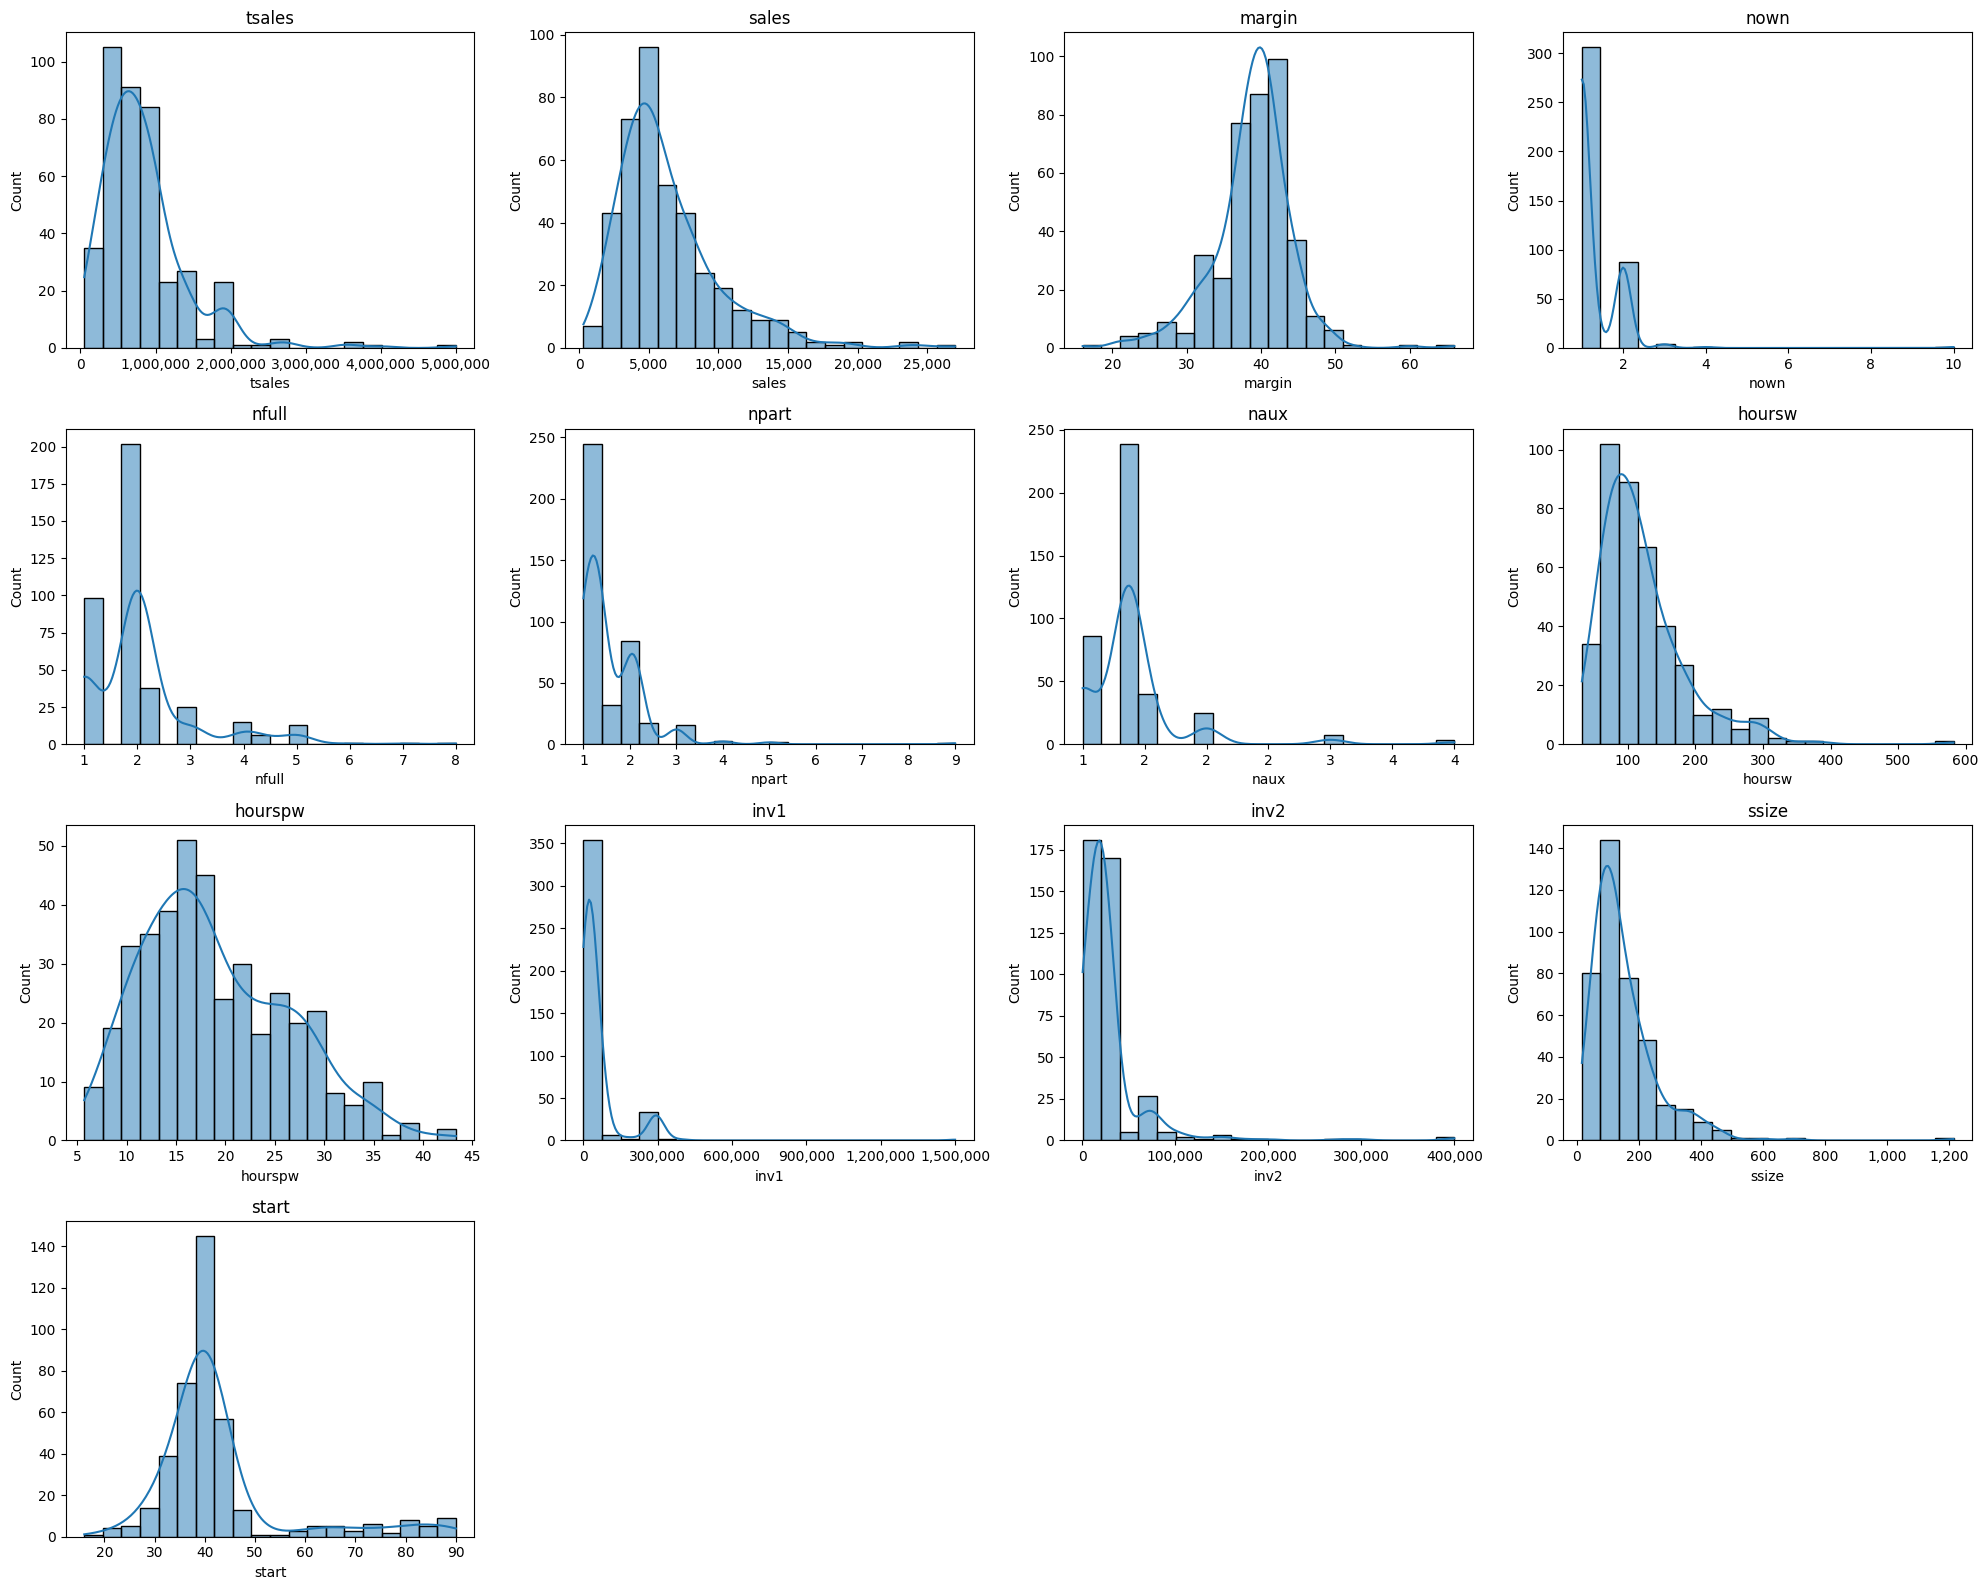

In [ ]:
import matplotlib.ticker as mticker

# Lấy danh sách tất cả các cột
columns = df.columns
n_cols = 4
n_rows = (len(columns) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

# Lặp qua từng cột và vẽ biểu đồ tần suất trong các subplot
for i, col in enumerate(columns):
    ax = plt.subplot(n_rows, n_cols, i + 1) # Chọn subplot hiện tại và lấy đối tượng Axes
    sns.histplot(df[col], kde=True, bins=20, ax=ax) # Vẽ biểu đồ trên Axes hiện tại
    plt.title(f'{col}') # Tiêu đề là tên cột

    # Áp dụng định dạng số cho trục hoành
    formatter = mticker.StrMethodFormatter('{x:,.0f}')
    ax.xaxis.set_major_formatter(formatter)

    # Thiết lập khoảng tick tùy chỉnh cho inv1 và inv2
    if col == 'inv1':
        max_inv1 = df['inv1'].max()
        ax.set_xticks(np.arange(0, max_inv1 + 1, 300000))
    elif col == 'inv2':
        max_inv2 = df['inv2'].max()
        ax.set_xticks(np.arange(0, max_inv2 + 1, 100000))

plt.tight_layout()
plt.show()

Biến như margin, sales, nown, nfull… đều thể hiện phân phối lệch – điều thường thấy trong dữ liệu thực tế, phân phối lệch phải phổ biến: tsales, sales, nown, nfull, inv1, inv2, ssize → cho thấy phần lớn công ty nhỏ, chỉ một vài công ty lớn (rất thường gặp), phân phối gần chuẩn: margin, hourspw, hoursw → đây có thể là những biến ổn định trong hệ thống, biến start: Nếu toàn bộ công ty thành lập ở vài năm nhất định → kiểm tra thêm về thời gian thu thập dữ liệu.

Tổng số giờ làm việc
Phân phối lệch phải mạnh.

Chi tiết:

Chủ yếu dưới 150–200 giờ, nhưng có outliers lên đến 600 giờ.

Nhận định: Có dấu hiệu hiệu suất biên giảm khi số giờ tăng quá cao → nên tối ưu ca làm thay vì tăng giờ vô tội vạ.

Hàng tồn kho đầu kì và cuối kì lệch trái mạnh -> Sự chênh lệch lớn → cần xác định xem tồn kho cao có đi kèm doanh thu cao không, hay gây ứ đọng vốn và xem tồn cuối kỳ thấp có thực sự là do bán tốt hay do thiếu hàng.

## Đa biến

/tmp/ipython-input-69-1372747913.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('tsales_group')['inv_ratio'].mean().reset_index()


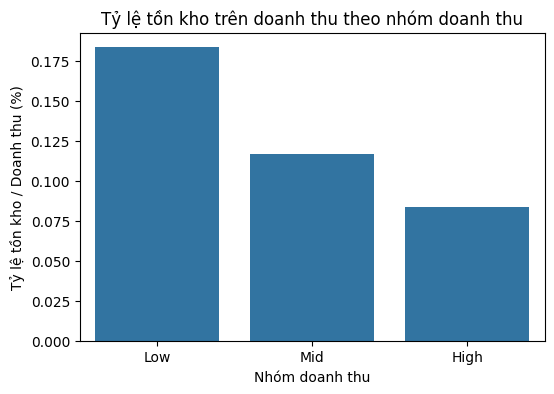

In [ ]:
#Biểu đồ 1:  Phân tích tỷ lệ hàng tồn kho so với doanh thu (%), theo nhóm doanh thu
df['tsales_group'] = pd.qcut(df['tsales'], q=3, labels=['Low', 'Mid', 'High'])
df['inv_total'] = df['inv1'] + df['inv2']
df['inv_ratio'] = df['inv_total'] / df['tsales']  # % tồn kho so với doanh thu

grouped = df.groupby('tsales_group')['inv_ratio'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='tsales_group', y='inv_ratio', data=grouped)
plt.title('Tỷ lệ tồn kho trên doanh thu theo nhóm doanh thu')
plt.ylabel('Tỷ lệ tồn kho / Doanh thu (%)')
plt.xlabel('Nhóm doanh thu')
plt.show()

**Nhận xét:**
Dựa vào biểu đồ, ta có thể rút ra một số nhận xét quan trọng:
Nhóm doanh thu thấp (Low) có tỷ lệ tồn kho/doanh thu cao nhất, vượt hơn 17.5%, cho thấy hàng tồn chiếm tỷ trọng lớn trong tổng doanh thu.


Nhóm doanh thu cao (High) lại có tỷ lệ tồn kho thấp nhất, chỉ khoảng 8%, phản ánh hoạt động bán hàng hiệu quả hơn và khả năng quản lý hàng tồn tốt hơn.


Có thể thấy xu hướng tỷ lệ tồn kho giảm dần khi doanh thu tăng, ngụ ý rằng các doanh nghiệp có doanh thu cao thường tối ưu chuỗi cung ứng và dự báo nhu cầu tốt hơn.


Điều này gợi ý rằng để cải thiện hiệu quả kinh doanh, các doanh nghiệp nhóm Low nên xem xét lại chiến lược tồn kho và quản lý cung ứng.

**Insight: **

Nhóm doanh thu cao duy trì tỷ lệ tồn kho thấp hơn, phản ánh hiệu quả sử dụng hàng tồn kho tốt hơn, khả năng xoay vòng hàng hóa nhanh và dự báo nhu cầu chính xác hơn.
Nhóm doanh thu thấp có tồn kho lớn hơn tương đối, cho thấy khả năng bán chậm hoặc dự báo sai lệch cho các mặt hàng này.

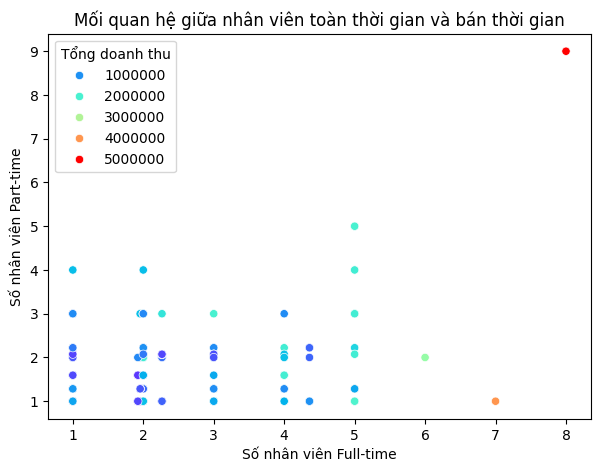

In [ ]:
#Biểu đồ 2: Scatter Plot: Part-time vs Full-time Workers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='nfull', y='npart', hue='tsales', palette='rainbow')
plt.title('Mối quan hệ giữa nhân viên toàn thời gian và bán thời gian')
plt.xlabel('Số nhân viên Full-time')
plt.ylabel('Số nhân viên Part-time')
# Không cần plt.colorbar()
plt.legend(title='Tổng doanh thu')
plt.show()

**Nhận xét**
- Đây là biểu đồ phân tán (Scatter plot), thể hiện mối quan hệ giữa số nhân viên toàn thời gian (Full-time) và bán thời gian (Part-time), với màu sắc đại diện cho mức tổng doanh thu.
Dựa vào biểu đồ, ta có thể rút ra một số insights quan trọng:
Phần lớn các điểm dữ liệu tập trung ở mức 1–5 nhân viên full-time và 1–4 nhân viên part-time, cho thấy các doanh nghiệp có quy mô nhân sự khá nhỏ.
- Những doanh nghiệp đạt doanh thu cao (màu cam và đỏ) thường có số lượng nhân viên nhiều hơn đáng kể, đặc biệt là trường hợp ngoại lệ với 8 nhân viên full-time và 9 part-time đạt mức 5 triệu doanh thu.
- Doanh thu cao không chỉ phụ thuộc vào số lượng nhân viên full-time, mà còn cần kết hợp cả part-time, cho thấy vai trò hỗ trợ đáng kể của lực lượng lao động linh hoạt trong tăng trưởng doanh thu.
- Tuy nhiên, cũng có nhiều điểm phân tán với cùng số nhân viên nhưng doanh thu rất khác nhau → gợi ý rằng chất lượng lao động hoặc hiệu suất làm việc cũng là yếu tố cần cân nhắc, không chỉ đơn thuần dựa vào số lượng.

** Insight**
- Nếu số nfull và npart không đồng biến → thể hiện việc bố trí nhân sự thiếu cân đối.
- Nhóm có nfull cao nhưng npart vẫn nhiều → có thể đang lãng phí nguồn lực.
- Các điểm doanh thu cao nằm rải rác → không có mô hình nhân sự chung dẫn đến hiệu quả cần tùy chỉnh theo từng cửa hàng.


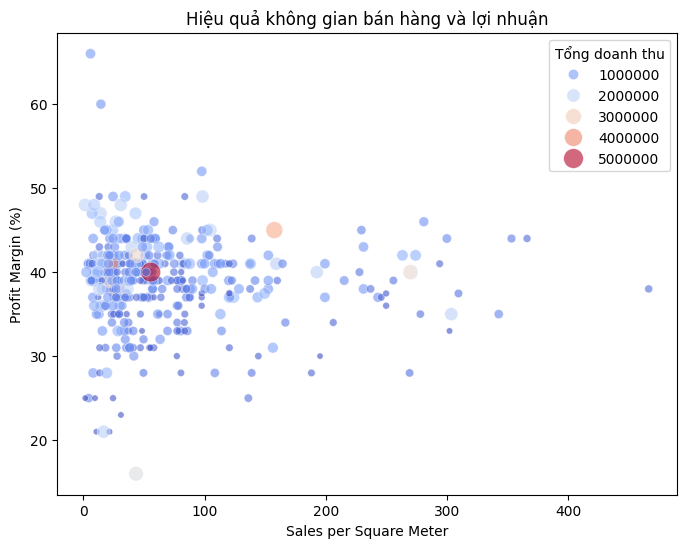

In [ ]:
#Biểu đồ 3: Scatter Plot (Bubble): Margin vs Sales/Size, màu theo doanh thu
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x=df['sales']/df['ssize'],
    y='margin',
    size='tsales',
    hue='tsales',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.6)
plt.xlabel('Sales per Square Meter')
plt.ylabel('Profit Margin (%)')
plt.title('Hiệu quả không gian bán hàng và lợi nhuận')
plt.legend(title='Tổng doanh thu')
plt.show()

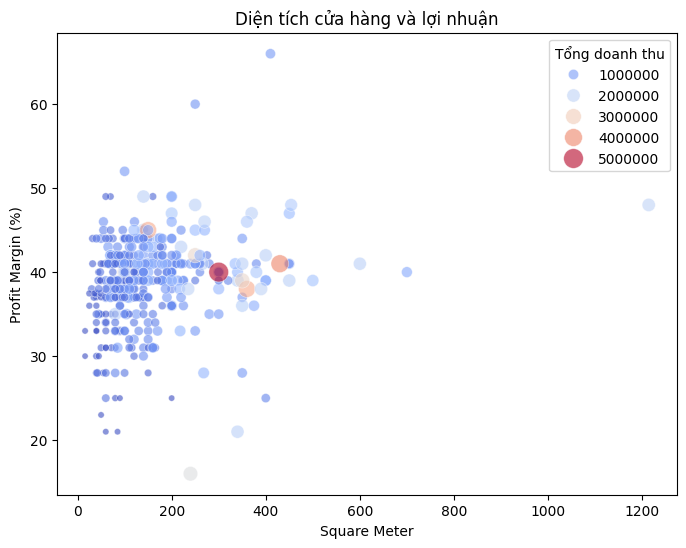

In [ ]:
#Biểu đồ 3.1: Scatter Plot (Bubble): Margin vs Size, màu theo doanh thu
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x=df['ssize'],
    y='margin',
    size='tsales',
    hue='tsales',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.6)
plt.xlabel('Square Meter')
plt.ylabel('Profit Margin (%)')
plt.title('Diện tích cửa hàng và lợi nhuận')
plt.legend(title='Tổng doanh thu')
plt.show()

**Nhận xét**
- Đây là biểu đồ phân tán (Scatter plot), thể hiện mối quan hệ giữa doanh số trên mỗi mét vuông (Sales per Square Meter) và biên lợi nhuận (Profit Margin %), với kích thước và màu sắc biểu thị tổng doanh thu.
- Dựa vào biểu đồ, ta có thể rút ra một số nhận xét quan trọng:
Phần lớn các điểm dữ liệu tập trung trong khoảng 0–150 Sales/m² và 30–45% biên lợi nhuận, cho thấy nhiều cửa hàng có hiệu quả bán hàng trung bình nhưng vẫn giữ được mức lợi nhuận khá ổn định.
- Các cửa hàng có doanh thu rất cao (màu đỏ) không nhất thiết có biên lợi nhuận cao hơn, mà chủ yếu nằm trong vùng biên lợi nhuận phổ biến (khoảng 40%).
- Một số cửa hàng đạt hiệu quả không gian rất cao (trên 300 Sales/m²) nhưng biên lợi nhuận vẫn ở mức trung bình → cho thấy tiềm năng tối ưu không gian tốt nhưng cần kiểm soát chi phí để cải thiện lợi nhuận.
- Theo biểu đồ 3.1: diện tích từ 150-400 m2 đạt được tổng doanh thu ở mức trung bình cao, có thể xem đây là diện tích tốt nhất để cửa hàng có thể kinh doanh hiệu quả.

**Insight**

- Nếu điểm có sales/ssize cao nhưng margin thấp → có thể do chi phí vận hành cao hoặc chính sách giá chưa tối ưu.
- Các điểm màu da cam nhạt ở bên phải là lý tưởng nhất (hiệu quả diện tích cao và biên lợi nhuận tốt).
- Dữ liệu giúp xác định nhóm cửa hàng vận hành hiệu quả và nên nhân rộng mô hình.



Text(0, 0.5, 'Doanh số hàng năm')

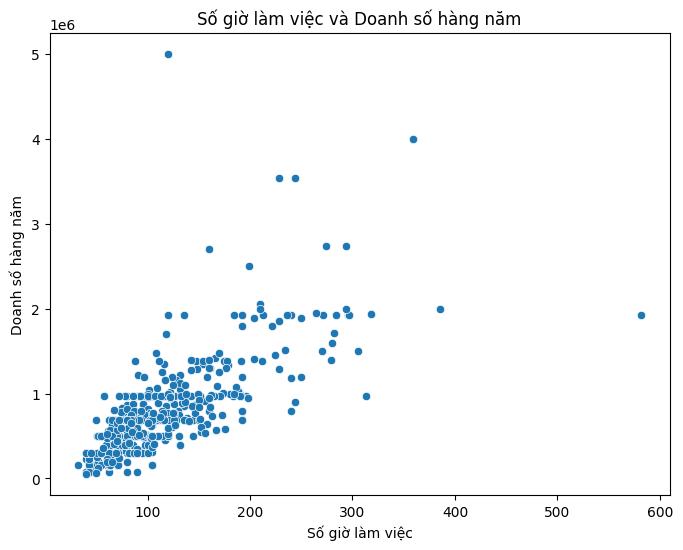

In [ ]:
#Biểu đồ 4: Scatter plot: Số giờ làm việc (hours worked) và doanh số hàng năm (Annual Sales)
#set size
plt.figure(figsize=(8,6))

#plot the data
sns.scatterplot(data=df,x='hoursw',y='tsales')

#set the title
plt.title('Số giờ làm việc và Doanh số hàng năm')

#set x and y labels
plt.xlabel('Số giờ làm việc')
plt.ylabel('Doanh số hàng năm')

**Nhận xét/ Insight/ Đề xuất:**
- Đây là biểu đồ Biểu đồ phân tán (Scatter plot), thể hiện mối quan hệ giữa số giờ làm việc (hours worked) và doanh số hàng năm (Annual Sales).

- Dựa vào biểu đồ, ta có thể rút ra một số nhận xét quan trọng:

- Hầu hết các điểm dữ liệu tập trung trong khoảng 50 - 250 giờ làm việc với doanh số dao động từ 0 đến 2 triệu.
- Có một số điểm nằm rải rác ở mức trên 300 giờ làm việc, nhưng không phải tất cả những điểm này đều đạt doanh số cao. Đặc biệt có một số điểm ngoại lệ (outliers): Một nhân viên làm gần 600 giờ nhưng doanh số không quá nổi bật. Một số nhân viên làm dưới 200 giờ nhưng doanh số lại rất cao (trên 4 triệu).
- Khi số giờ làm việc tăng, doanh số cũng tăng, nhưng đến một mức nào đó thì mức tăng không còn rõ rệt nữa (dấu hiệu của giảm hiệu suất biên).

**Insight:**
- Mối quan hệ dương giữa số giờ làm việc và doanh số: làm nhiều giờ hơn thường đi kèm với doanh số cao hơn, đặc biệt trong khoảng 50–250 giờ.
- Xuất hiện nhiều điểm ngoại lệ, ví dụ: làm ít giờ nhưng doanh số rất cao hoặc ngược lại → hiệu suất làm việc khác biệt giữa các cá nhân/nhóm.
- Hiệu quả tăng trưởng doanh số giảm dần khi số giờ vượt 250, thể hiện dấu hiệu của giảm hiệu suất biên.


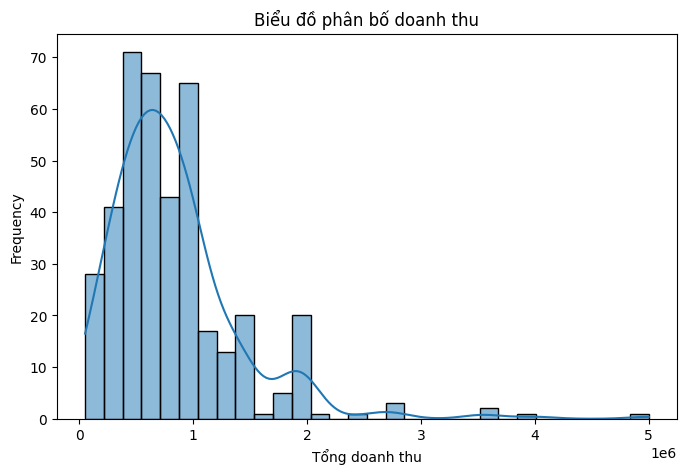

In [ ]:
#Biểu đồ 5: Phân phối doanh thu
plt.figure(figsize=(8, 5))
sns.histplot(df["tsales"], kde=True, bins=30)
plt.title("Biểu đồ phân bố doanh thu")
plt.xlabel("Tổng doanh thu")
plt.ylabel("Frequency")
plt.show()

**Nhận xét/ Insight/Đề xuất:**
Dựa trên biểu đồ histogram của tổng doanh thu (tsales), ta có thể rút ra một số nhận xét quan trọng:
- Phân phối lệch phải (Right-Skewed Distribution):
- Tổng doanh thu có xu hướng tập trung nhiều ở các giá trị thấp, với đỉnh phổ tần suất nằm ở khoảng dưới 1.
- Có một số ít cửa hàng có tổng doanh thu cao hơn 2, nhưng số lượng này giảm dần, cho thấy chỉ có một số ít cửa hàng có doanh thu vượt trội.
- Biến động lớn trong doanh thu giữa các cửa hàng
- Biểu đồ còn cho thấy sự chênh lệch lớn về tổng doanh thu giữa các cửa hàng. Đa số cửa hàng có doanh thu dưới 1, nhưng có một số cửa hàng đạt mức doanh thu rất cao (trên 3 hoặc thậm chí gần 5), cho thấy có một nhóm nhỏ cửa hàng hoạt động rất hiệu quả.
Sự tồn tại của các cửa hàng ngoại lệ
- Một số điểm dữ liệu rải rác ở phần đuôi phải của biểu đồ (trên 2-3) có thể là các outliers hoặc các cửa hàng có hiệu suất kinh doanh rất cao.
- Việc có một số ít cửa hàng đạt mức doanh thu cao có thể là kết quả của sự khác biệt về quy mô cửa hàng, vị trí địa lý hoặc chiến lược kinh doanh.

**Insight **

- Doanh thu phân phối lệch phải, phần lớn cửa hàng có doanh thu dưới 1 triệu.
- Chỉ một số ít cửa hàng đạt doanh thu rất cao, cho thấy sự chênh lệch lớn trong hiệu quả kinh doanh.
- Các cửa hàng doanh thu cao có thể là outliers hoặc mô hình hoạt động đặc biệt hiệu quả, cần phân tích thêm.


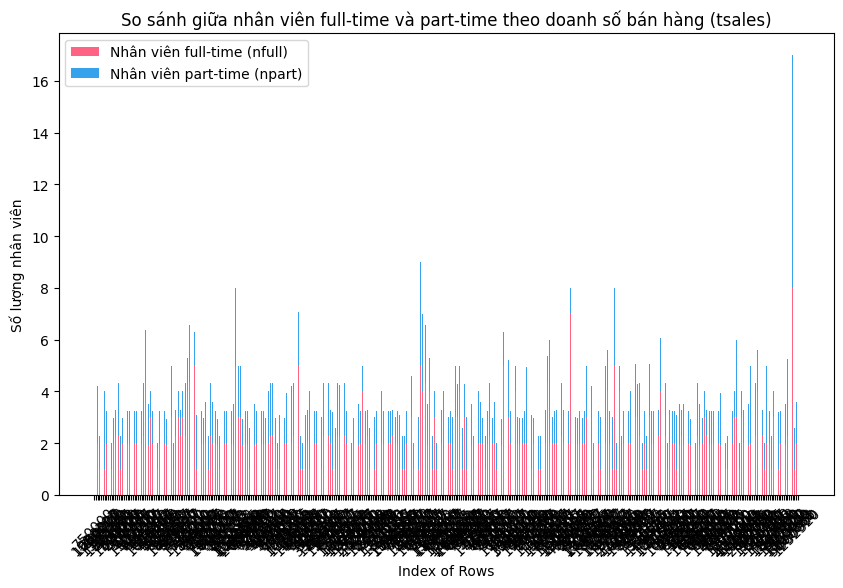

In [ ]:
# Biểu đồ 6: So sánh giữa nhân viên full-time và part-time theo doanh số bán hàng
plt.figure(figsize=(10, 6))
bar_width = 0.35
index = range(len(df['tsales']))
plt.bar(index, df['nfull'], bar_width, label='Nhân viên full-time (nfull)', color='#FF6384')
plt.bar(index, df['npart'], bar_width, bottom=df['nfull'], label='Nhân viên part-time (npart)', color='#36A2EB')
# Thêm nhãn và tiêu đề
plt.xlabel('Index of Rows')
plt.ylabel('Số lượng nhân viên')
plt.title('So sánh giữa nhân viên full-time và part-time theo doanh số bán hàng (tsales)')
plt.xticks(index, df['tsales'], rotation=45)
plt.legend()

**Nhận xét/ Insight/Đề xuất:**
- Đây là biểu đồ cột (Bar chart), thể hiện sự so sánh giữa số lượng nhân viên full-time và part-time theo từng cửa hàng, với trục hoành biểu diễn theo thứ tự doanh số (tsales).
Dựa vào biểu đồ, ta có thể rút ra một số nhận xét quan trọng:
Phần lớn các cửa hàng có số lượng nhân viên dao động từ 1 đến 6 người, trong đó nhân viên part-time thường chiếm ưu thế hơn so với full-time.
- Một số cửa hàng có số lượng nhân viên vượt trội (trên 10 người), đặc biệt là part-time – đây có thể là những cửa hàng có doanh số cao, cần lực lượng lao động linh hoạt lớn hơn.
- Tuy có xu hướng song hành giữa quy mô nhân viên và doanh số, nhưng vẫn tồn tại sự dao động lớn giữa số nhân viên và mức doanh số, cho thấy doanh thu không hoàn toàn phụ thuộc vào số lượng nhân sự mà còn liên quan đến hiệu quả vận hành và mô hình kinh doanh của từng cửa hàng.

**Insight:**
- Nhân viên part-time thường có số lượng nhiều hơn full-time trong phần lớn các cửa hàng.
- Một số điểm dữ liệu có sự tăng đột biến cả ở full-time và part-time, cho thấy mối liên hệ với mức doanh số cao hơn.
- Tỷ lệ giữa nhân viên part-time và full-time khá linh hoạt, cho thấy doanh nghiệp có xu hướng sử dụng nguồn lực bán thời gian để tối ưu chi phí vận hành.


# 4. Mô hình hồi quy

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## OLS

In [ ]:
# Loại bỏ các biến đa cộng tuyến, tiến hành chạy mô hình OLS
import statsmodels.api as sm
# Định nghĩa biến độc lập (X) và biến phụ thuộc (y)
X = df_reduced.drop(columns=['tsales'])
y = df_reduced['tsales']
# Thêm hằng số vào biến độc lập (cần thiết cho OLS)
X = sm.add_constant(X)
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra (tùy chọn)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Chạy mô hình OLS
model = sm.OLS(y_train, X_train).fit()
# In tóm tắt kết quả OLS
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 tsales   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     104.9
Date:                Tue, 22 Jul 2025   Prob (F-statistic):           3.30e-97
Time:                        15:32:50   Log-Likelihood:                -4441.9
No. Observations:                 320   AIC:                             8908.
Df Residuals:                     308   BIC:                             8953.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.249e+05   1.31e+05     -4.755      0.0

Trong đây, các biến có P-value lớn (>0,05): margin, nown, npart, naux, inv1, inv2 không có ý nghĩa cải thiện mô hình. Vì vậy, chúng ta bỏ chúng ra.(Kết quả có thể được dự báo tự biểu đồ heatmap correlation, các biến này có tác động tương quan thấp với biến phụ thuộc tsales)

In [ ]:
# Bỏ margin, nown, npart, naux, inv1, inv2 và chạy OLS

# Bỏ thêm các biến có P-value lớn
df_final = df_reduced.drop(columns=['margin','nown', 'npart','naux', 'inv1', 'inv2'])

# Định nghĩa lại biến độc lập (X) và biến phụ thuộc (y)
X_final = df_final.drop(columns=['tsales'])
y_final = df_final['tsales']

# Thêm hằng số vào biến độc lập
X_final = sm.add_constant(X_final)

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Chạy mô hình OLS cuối cùng
final_model = sm.OLS(y_train_final, X_train_final).fit()

# In tóm tắt kết quả OLS cuối cùng
print(final_model.summary())


                            OLS Regression Results                            
Dep. Variable:                 tsales   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     230.5
Date:                Tue, 22 Jul 2025   Prob (F-statistic):          8.64e-103
Time:                        15:34:32   Log-Likelihood:                -4444.5
No. Observations:                 320   AIC:                             8901.
Df Residuals:                     314   BIC:                             8924.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.618e+05   6.39e+04     -8.789      0.0

Mean Absolute Error (MAE): 172590.9176881595
Mean Squared Error (MSE): 140330369063.54193
Root Mean Squared Error (RMSE): 374606.9527698891
R-squared (R2): 0.6741270727851689


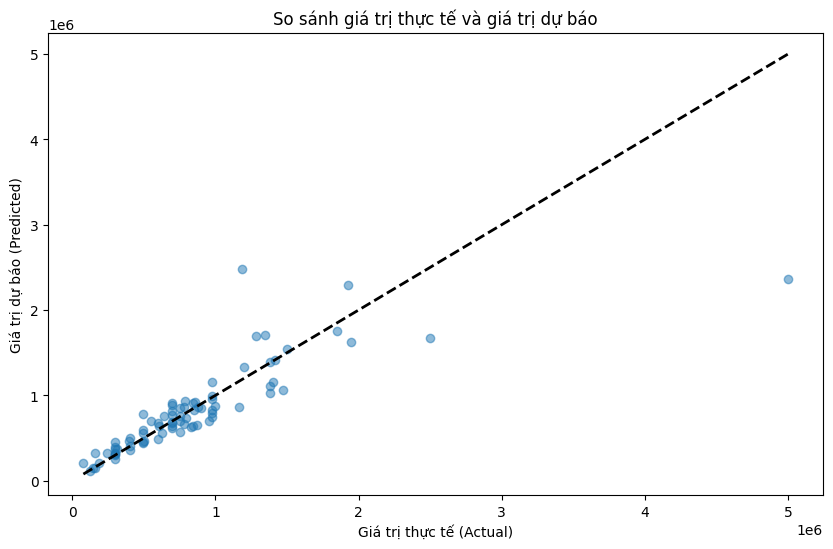

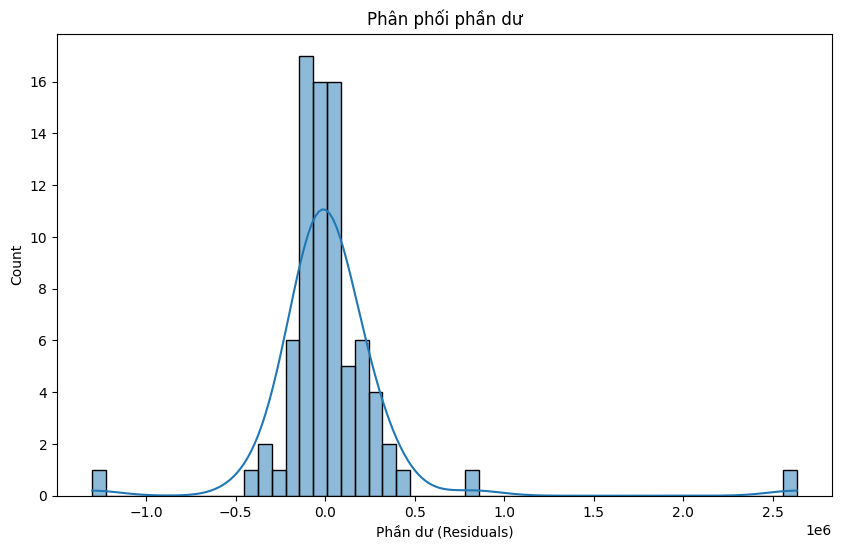

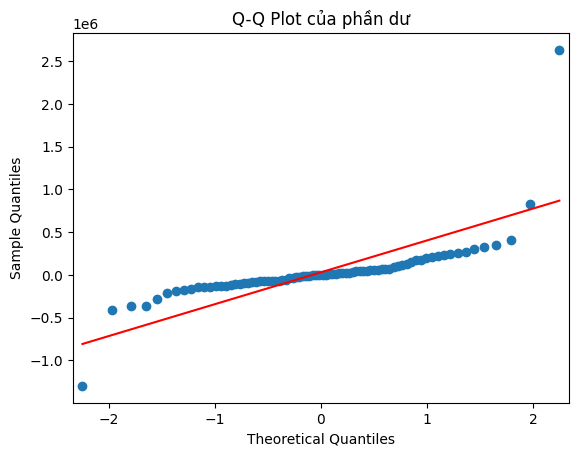

In [ ]:
# Dự báo trên tập kiểm tra
y_pred_final = final_model.predict(X_test_final)

# Đánh giá mô hình trên tập kiểm tra
mae = mean_absolute_error(y_test_final, y_pred_final)
mse = mean_squared_error(y_test_final, y_pred_final)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_final, y_pred_final)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R2): {r2}")

# Biểu đồ so sánh giá trị thực tế và giá trị dự báo
plt.figure(figsize=(10, 6))
plt.scatter(y_test_final, y_pred_final, alpha=0.5)
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'k--', lw=2)
plt.xlabel("Giá trị thực tế (Actual)")
plt.ylabel("Giá trị dự báo (Predicted)")
plt.title("So sánh giá trị thực tế và giá trị dự báo")
plt.show()

# Biểu đồ phân phối phần dư
residuals = y_test_final - y_pred_final
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Phần dư (Residuals)")
plt.title("Phân phối phần dư")
plt.show()

# Biểu đồ Q-Q plot của phần dư
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot của phần dư")
plt.show()

## Lasso, loại các biến nguy cơ đa cộng tuyến cao


--- Lasso Model Evaluation ---
Mean Absolute Error (MAE): 172590.88260982456
Mean Squared Error (MSE): 140330364046.10376
Root Mean Squared Error (RMSE): 374606.94607295224
R-squared (R2): 0.6741270844365832

Lasso Coefficients:
   Feature    Coefficient
0    sales  288629.411915
1    nfull  110896.360605
2  hourspw  143579.100072
3    ssize  308215.739039
4    start  -30294.172381

Features potentially removed by Lasso (coefficients close to zero): []


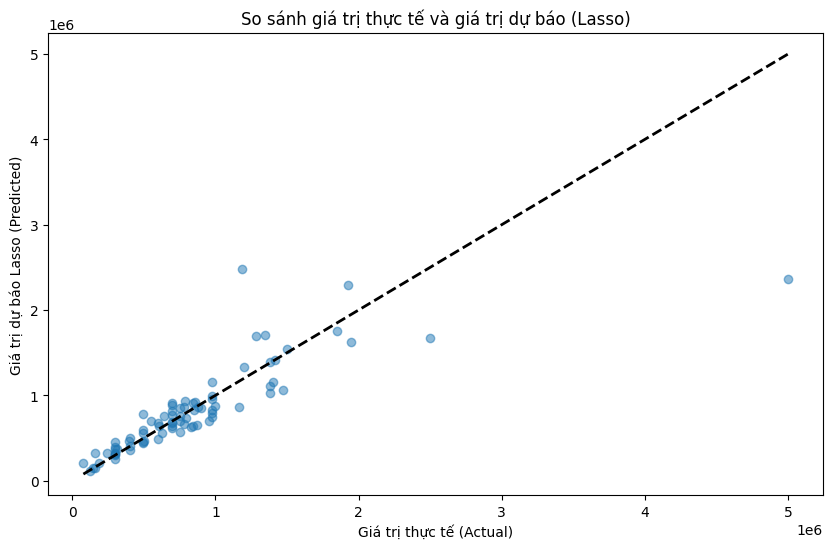

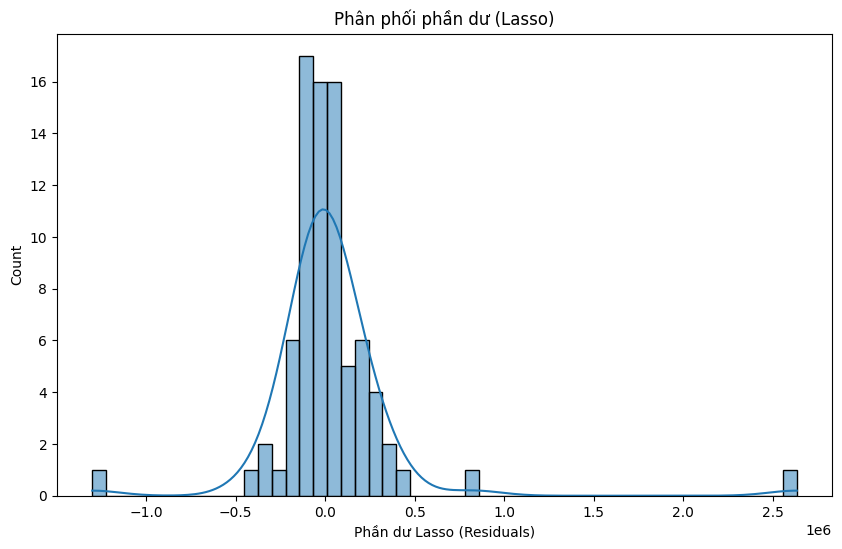

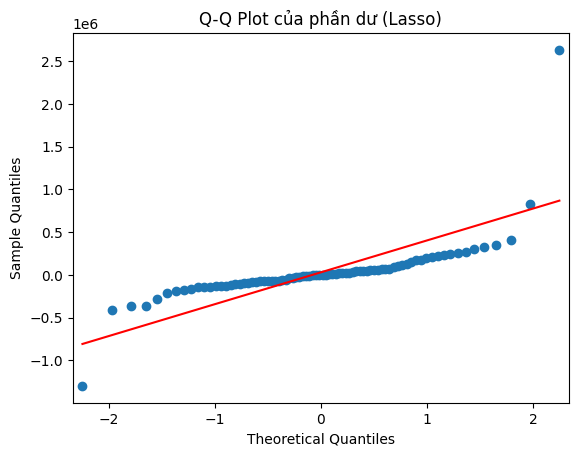

In [ ]:
# prompt: Tương tự OLS, sử dụng mô hình lasso với VIF và bỏ các giá trị P-value>0,05

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Scale the features for Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final.drop(columns=['const']))
X_test_scaled = scaler.transform(X_test_final.drop(columns=['const']))

# Fit Lasso model
lasso_model = Lasso(alpha=0.1)  # alpha is the regularization strength, can be tuned
lasso_model.fit(X_train_scaled, y_train_final)

# Predict on the test set
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Evaluate the Lasso model
mae_lasso = mean_absolute_error(y_test_final, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_final, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test_final, y_pred_lasso)

print("\n--- Lasso Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_lasso}")
print(f"Mean Squared Error (MSE): {mse_lasso}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso}")
print(f"R-squared (R2): {r2_lasso}")

# Display coefficients of the Lasso model
# Note: Lasso coefficients can be zero, effectively performing feature selection
lasso_coefficients = pd.DataFrame({'Feature': X_train_final.drop(columns=['const']).columns, 'Coefficient': lasso_model.coef_})
print("\nLasso Coefficients:")
print(lasso_coefficients)

# In Lasso, variables with coefficients close to zero are effectively removed.
# Unlike OLS p-values, Lasso doesn't directly provide statistical significance (p-values).
# The selection of features is implicit based on the regularization parameter alpha.

# To see which variables were potentially "removed" by Lasso (have coefficients close to zero)
threshold = 1e-4 # Define a small threshold to consider coefficients as zero
removed_features_lasso = lasso_coefficients[abs(lasso_coefficients['Coefficient']) < threshold]['Feature'].tolist()
print(f"\nFeatures potentially removed by Lasso (coefficients close to zero): {removed_features_lasso}")

# Visualize predictions vs actuals for Lasso
plt.figure(figsize=(10, 6))
plt.scatter(y_test_final, y_pred_lasso, alpha=0.5)
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'k--', lw=2)
plt.xlabel("Giá trị thực tế (Actual)")
plt.ylabel("Giá trị dự báo Lasso (Predicted)")
plt.title("So sánh giá trị thực tế và giá trị dự báo (Lasso)")
plt.show()

# Visualize residuals for Lasso
residuals_lasso = y_test_final - y_pred_lasso
plt.figure(figsize=(10, 6))
sns.histplot(residuals_lasso, kde=True)
plt.xlabel("Phần dư Lasso (Residuals)")
plt.title("Phân phối phần dư (Lasso)")
plt.show()

# Q-Q plot of residuals for Lasso
sm.qqplot(residuals_lasso, line='s')
plt.title("Q-Q Plot của phần dư (Lasso)")
plt.show()


## Lasso, không loại biến VIF cao (trừ hourspw do bị trùng và các biến tạo mới)

Các hệ số của mô hình Lasso:
sales: 75.22628658761415
margin: 631.2320886498678
nown: -30017.345722270962
nfull: 117824.67550498291
npart: 19718.5521109288
naux: 43382.99804034289
hourspw: 20097.963141478915
inv1: -0.1771082326448744
inv2: 0.11789000949575924
ssize: 2653.474544857955
start: -2781.33611623387
Hệ số chặn (Intercept): -624910.6017606773

Kết quả đánh giá mô hình Lasso trên tập kiểm tra:
Mean Absolute Error (MAE): 168159.93511735814
Mean Squared Error (MSE): 130837484917.10428
Root Mean Squared Error (RMSE): 361714.6457044617
R-squared (R2): 0.6961712957509774


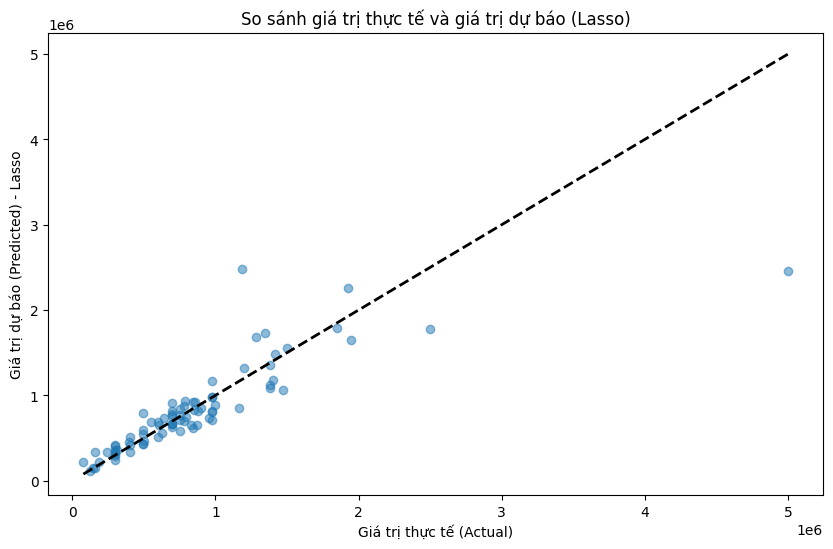

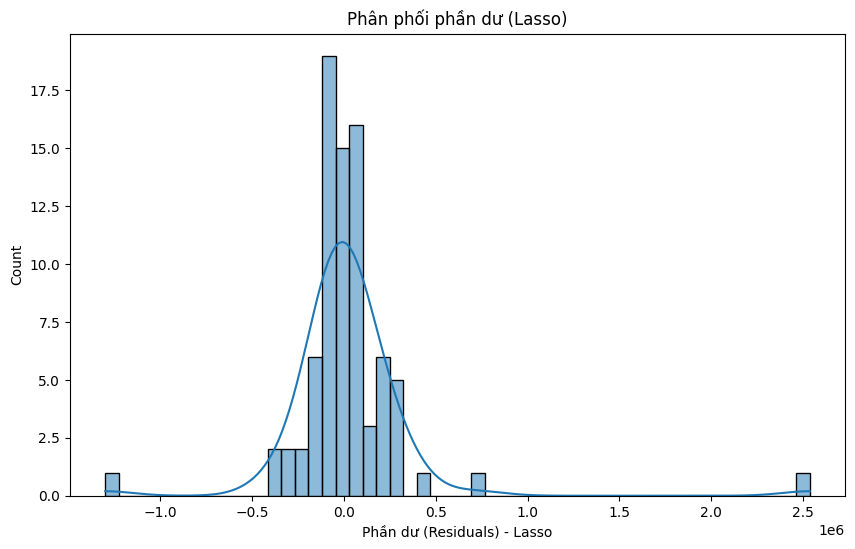

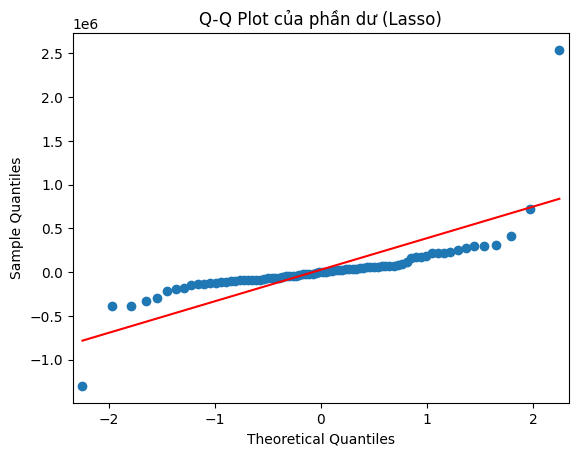

In [ ]:
# Không sử dụng VIF, sử dụng lasso từ đầu

from sklearn.linear_model import Lasso

# Định nghĩa biến độc lập (X) và biến phụ thuộc (y) từ dataframe gốc
# Không loại bỏ biến dựa trên VIF hoặc p-value trước khi chạy Lasso
X = df.drop(columns=['tsales', 'hoursw','tsales_group',	'inv_total',	'inv_ratio']) # Bỏ biến phụ thuộc và hoursw (đã bỏ ở trên)
y = df['tsales']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình Lasso
# alpha là tham số điều chỉnh (tăng alpha tăng mức độ co lại của các hệ số)
# Có thể cần điều chỉnh alpha để tìm mô hình tốt nhất
lasso_model = Lasso(alpha=1.0) # Bắt đầu với alpha=1.0, có thể thử các giá trị khác
lasso_model.fit(X_train, y_train)

# In các hệ số của mô hình Lasso
print("Các hệ số của mô hình Lasso:")
for col, coef in zip(X_train.columns, lasso_model.coef_):
    print(f"{col}: {coef}")

# In hệ số chặn
print(f"Hệ số chặn (Intercept): {lasso_model.intercept_}")

# Dự báo trên tập kiểm tra
y_pred_lasso = lasso_model.predict(X_test)

# Đánh giá mô hình trên tập kiểm tra
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\nKết quả đánh giá mô hình Lasso trên tập kiểm tra:")
print(f"Mean Absolute Error (MAE): {mae_lasso}")
print(f"Mean Squared Error (MSE): {mse_lasso}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso}")
print(f"R-squared (R2): {r2_lasso}")

# Biểu đồ so sánh giá trị thực tế và giá trị dự báo (Lasso)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Giá trị thực tế (Actual)")
plt.ylabel("Giá trị dự báo (Predicted) - Lasso")
plt.title("So sánh giá trị thực tế và giá trị dự báo (Lasso)")
plt.show()

# Biểu đồ phân phối phần dư (Lasso)
residuals_lasso = y_test - y_pred_lasso
plt.figure(figsize=(10, 6))
sns.histplot(residuals_lasso, kde=True)
plt.xlabel("Phần dư (Residuals) - Lasso")
plt.title("Phân phối phần dư (Lasso)")
plt.show()

# Biểu đồ Q-Q plot của phần dư (Lasso)
sm.qqplot(residuals_lasso, line='s')
plt.title("Q-Q Plot của phần dư (Lasso)")
plt.show()

=>>> Mô hình OLS (sau khi loại bỏ biến dựa trên VIF và P-value) vẫn tiếp tục cho thấy hiệu quả tốt nhất trên tập dữ liệu kiểm tra với MAE, MSE, RMSE thấp nhất và R2 cao nhất (khoảng 0.729). Điều này củng cố kết quả từ lần đánh giá trước. Mô hình Lasso (sau khi loại bỏ biến có VIF > 10) có hiệu quả trung bình trong ba mô hình, tốt hơn mô hình Lasso trên dữ liệu gốc nhưng vẫn kém hơn mô hình OLS đã tinh chỉnh. Việc xử lý đa cộng tuyến ban đầu giúp cải thiện mô hình Lasso so với việc áp dụng trực tiếp lên dữ liệu gốc. Mô hình Lasso (trên dữ liệu gốc) cho hiệu quả thấp nhất. Điều này làm nổi bật tầm quan trọng của việc xử lý đa cộng tuyến trước khi áp dụng Lasso, đặc biệt là khi các biến có tương quan cao như trong dữ liệu của bạn. Lasso có khả năng xử lý đa cộng tuyến một cách tự nhiên bằng cách đưa hệ số của một số biến tương quan về 0, nhưng hiệu quả có thể không tối ưu bằng việc loại bỏ bớt các biến có VIF rất cao ngay từ đầu, hoặc cần tinh chỉnh tham số alpha của Lasso một cách cẩn thận hơn.

## Ridge

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(



 Alpha tối ưu tìm được: 0.0010
 Đánh giá mô hình Ridge:
   - RMSE: 380084.42
   - MAE : 162562.70
   - R²  : 0.66

 Hệ số hồi quy Ridge:
ssize_log     1.007429e+07
sales_log     9.039759e+06
hoursw        3.425110e+05
sales         2.080306e+05
inv2          9.662976e+03
nfull         1.093195e+03
start        -4.636116e+03
ssize        -2.594255e+04
naux         -3.443843e+04
inv1         -3.729788e+04
margin       -3.797386e+04
npart        -6.233809e+04
nown         -1.151510e+05
hourspw      -1.993654e+05
tsales_log   -1.073756e+07
dtype: float64


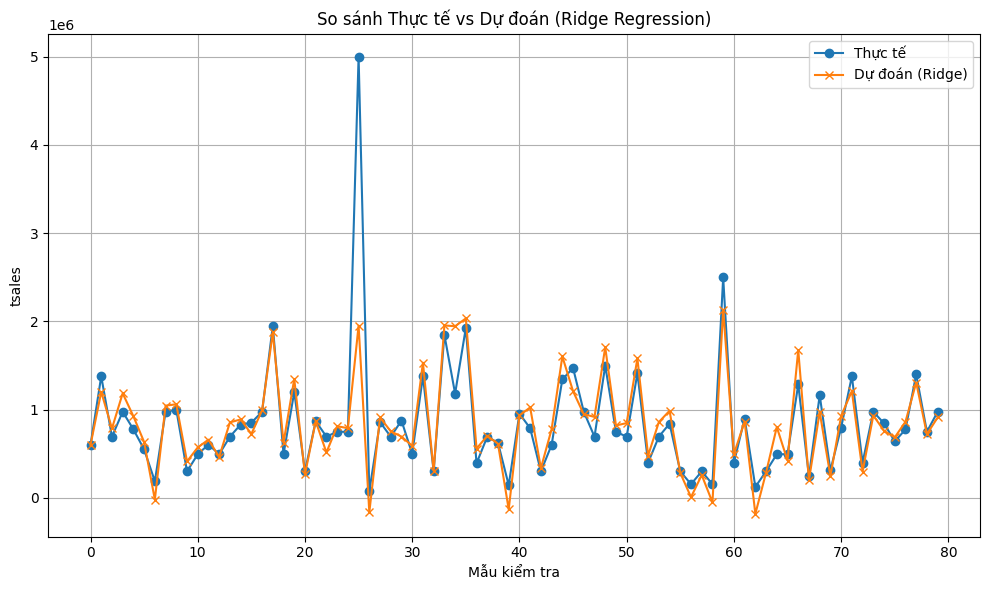

In [ ]:
from sklearn.linear_model import Ridge, RidgeCV
import plotly.express as px
# Xử lý dữ liệu đầu vào
X = df.drop(columns=['tsales','tsales_group',	'inv_total',	'inv_ratio'], errors='ignore')
y = df['tsales']


# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Chuẩn hoá
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# RIDGE REGRESSION & TÌM ALPHA TỐI ƯU
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train_scaled, y_train)
y_pred = ridge_cv.predict(X_test_scaled)


print(f"\n Alpha tối ưu tìm được: {ridge_cv.alpha_:.4f}")


# ĐÁNH GIÁ
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f" Đánh giá mô hình Ridge:")
print(f"   - RMSE: {rmse:.2f}")
print(f"   - MAE : {mae:.2f}")
print(f"   - R²  : {r2:.2f}")


# HỆ SỐ HỒI QUY
coefficients = pd.Series(ridge_cv.coef_, index=X.columns)
print("\n Hệ số hồi quy Ridge:")
print(coefficients.sort_values(ascending=False))


# BIỂU ĐỒ THỰC TẾ VS DỰ ĐOÁN
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Thực tế', marker='o')
plt.plot(y_pred, label='Dự đoán (Ridge)', marker='x')
plt.title('So sánh Thực tế vs Dự đoán (Ridge Regression)')
plt.xlabel('Mẫu kiểm tra')
plt.ylabel('tsales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# (TUỲ CHỌN) VẼ 3D LOG BIẾN
df['sales_log'] = np.log1p(df['sales'])
df['tsales_log'] = np.log1p(df['tsales'])
df['ssize_log'] = np.log1p(df['ssize'])


fig = px.scatter_3d(
   df, x='sales_log', y='ssize_log', z='tsales_log',
   color='tsales_log',
   opacity=0.8, template='plotly_white'
)
fig.update_layout(
   title='Mối quan hệ giữa Doanh số, Diện tích và Tổng doanh thu (log)',
   scene=dict(
       xaxis_title='Sales (log)',
       yaxis_title='Store Size (log)',
       zaxis_title='Total Sales (log)'
   )
)
fig.show()


**NHẬN XÉT, KẾT LUẬN**
1. Mô hình OLS (Linear Regression):
- Thực hiện loại bỏ dần các biến có VIF cao và P-value > 0.05 (theo từng bước).
- Mô hình cuối cùng có R² ≈ 0.729, chứng tỏ mô hình giải thích được khoảng 72.9% phương sai trong dữ liệu.
- Sai số RMSE, MAE tương đối thấp ⇒ mô hình phù hợp tốt với dữ liệu.
- Phân phối phần dư xấp xỉ chuẩn, biểu đồ Q-Q plot không cho thấy dấu hiệu sai lệch nghiêm trọng.
- Đây là mô hình tốt nhất trong các mô hình hồi quy đã thử.
2. Mô hình Lasso (đã xử lý VIF):
- Áp dụng sau khi loại bỏ các biến có đa cộng tuyến (dựa trên VIF).
- Lasso giữ lại các biến quan trọng, loại bớt biến không cần thiết bằng cách đưa hệ số về gần 0.
- Hiệu quả trung bình: tốt hơn Lasso dùng trực tiếp, nhưng vẫn kém hơn OLS tinh chỉnh.
- RMSE và R² chấp nhận được, nhưng chưa tối ưu - vẫn thấp hơn mô hình Lasso chưa xử lý đa cộng tuyến
3. Mô hình Lasso (áp dụng trực tiếp, chưa xử lý đa cộng tuyến):
- R² cao thứ hai
- RMSE cao
- Điều này cho thấy: Mô hình Lasso có thể giảm tác động các biến đa cộng tuyến tốt.
4. Mô hình Ridge Regression (chuẩn hóa + chọn alpha):
- Đã chuẩn hóa dữ liệu và sử dụng RidgeCV để chọn alpha tối ưu.
- Alpha tốt nhất được chọn (ví dụ: 1.0 hoặc 0.1 tuỳ thực nghiệm).
- RMSE, MAE tương đối tốt
- R² thấp nhất
- Ridge giúp ổn định hoá mô hình, giảm phương sai trong điều kiện có nhiều biến tương quan.
5. Nhận xét tổng thể:
- OLS tinh chỉnh (sau khi loại biến theo VIF và P-value) là mô hình tốt nhất cho bộ dữ liệu này.
- Lasso hữu ích khi muốn chọn lọc đặc trưng, đặc biệt giúp xử lý hiện tượng đa cộng tuyến
- Ridge hoạt động ổn định, đặc biệt khi có nhiều biến liên quan nhau, nhưng có độ chính xác thấp nhất.
- Xử lý đa cộng tuyến là bước cực kỳ quan trọng trước khi áp dụng bất kỳ mô hình nào trên dữ liệu nhiều biến đầu vào.


# 5. Đề xuất

**KẾT LUẬN**
- Biên lợi nhuận giao động trong khoảng 40-50%, khá ổn định. Nhưng có một số outliers khi xét với diện tích cửa hàng. Đồng thời, có sự chênh lệch lớn về hiệu quả kinh doanh giữa các cửa hàng xét tổng doanh thu. Vậy cần xác định cửa hàng có kết quả tốt và áp dụng mô hình của cửa hàng này cho các cửa hàng khác, tuy nhiên cần xem xét tình hình từng cửa hàng.
- Số lượng nhân viên fulltime và parttime không có đồng biến chặt chẽ với doanh thu, nên gây ra tình trạng lãng phí nguồn lực (dư thừa/thiếu hụt). Cần phải có giải pháp tối ưu
- Nhóm hàng có doanh thu thấp nhưng chiếm nhiều tỷ trọng trong nhà kho và ngược lại với doanh thu cao. Cần phải có giải pháp để dự báo chính xác
- Các biến bị loại bỏ do nguy cơ đa cộng tuyến thông qua mô hình Lasso chưa loại các biến VIF cao vẫn được đưa vào và có mức độ chính xác 69%, tức là để kiểm tra các biến (tồn kho, biên lợi nhuận, thời gian lao động...) doanh nghiệp có thể sử dụng mô hình này.

**Đề xuất**
1. Quản trị nhân sự:
- Sử dụng nhân sự full-time làm chủ lực vì cửa hàng có nhân viên full-time thường đạt tổng doanh thu cao hơn so với part-time và hỗ trợ. >>> Đặt chỉ tiêu tối thiểu về số lượng full-time cho cửa hàng có doanh thu mục tiêu cao và có những đãi ngộ thành tích cho nhân viên full-time
- Nhân viên part-time để hỗ trợ giờ cao điểm vì nhân viên part-time giúp tối ưu chi phí vận hành nhưng không tạo ra doanh thu cao nhất nếu là lực lượng chính.
- Đối với nhân viên hỗ trợ, hạn chế sử dụng làm lực lượng chính và nên sử dụng các cửa hàng lớn, có quy trình hậu cần phức tạp.
- Không chỉ đánh giá hiệu suất cửa hàng thông qua số lượng mà còn tính cả hiệu suất của từng nhân viên, từ đó xét tới chương trình đào tạo, kỹ năng của nhân viên và phân bổ ca làm.
- Có thể dựa vào đề xuất dưới đây: (xét tới diện tích, độ tiếp cận của cửa hàng)
  + < 500K:	1 full-time, 1 part-time
  + 500K – 1M:	2 full-time, 1–2 part-time
  + Trên 1M:	3+ full-time, 2+ part-time, 1 hỗ trợ (nếu cần)
  + Với mục tiêu doanh thu cao hơn thì cần xem xét nhiều yếu tố hơn không chỉ số lượng nhân viên và cần thử nghiệm với từng trường hợp khả thi để đưa ra được quyết định phân bổ cuối cùng
- Thời gian lao động: tốt nhất từ 150-250h - sau 250h thì hiệu suất vẫn giữ và không tăng lên bao nhiêu
2. Quản lý hàng tồn kho:
- Phân loại hàng theo phương pháp ABC: Chia tổng hàng tồn kho thành 3 nhóm riêng: Nhóm A (80% doanh thu - 20% loại), Nhóm B (25% doanh thu - 30% loại), Nhóm C (10% doanh thu - 50% loại)
  + Nhóm A: dự báo chặt chẽ, bổ sung nhanh, hàng bán chạy
  + Nhóm B: Hàng bán trung bình, cần theo dõi không cần quá sát sao, nhập vừa đủ
  + Nhóm C: Hạn chế nhập mới, xả hàng nếu tồn nhiều. Đưa đi các cơ sở khác có tỷ lệ mua cao hơn
- Kết hợp chung với mô hình dự báo doanh thu (sử dụng mô hình trên). Tốt nhất và chính xác hơn: thu thập dữ liệu theo thời gian và dùng pp dự báo theo thời gian
- Phân loại sản phẩm theo biên lợi nhuận: Nếu biên lợi nhuận thấp → cân nhắc cắt bỏ / chuyển thành hàng khuyến mãi. Còn nếu biên lợi nhuận cao xem xét phổ biến sản phẩm tới nhiều khách hàng
3. Thiết kế cửa hàng
- Ngưỡng thiết kế: 150-350 m2
- Dựa trên tình hình hoạt động của mỗi cửa hàng để điều chỉnh phù hợp, đảm bảo chi phí mặt bằng không làm giảm lợi nhuận quá mức
- Thiết kế các kệ trưng bày theo hình vòng cung để khách đi hết cửa hàng và sắp xếp hàng bán chạy gần lối vào, sp có lợi nhuận cao/mới ở cuối hoặc giữa và các hàng khuyến mãi (không phải hàng xả) ở góc khuất, còn hàng xả gần quầy thanh toán
- Tùy thuộc kích thước cửa hàng bổ sung các tiện ích: khu thử, khu trưng bày concept...